# Part 1: Gender Ratio Classification
This notebook covers **Part 1.0 (EDA)** and provides a **structured skeleton for Part 1.1**.

Datasets:
- worldbank_gender_2021.csv
- countries_regions.xlsx

In [1]:
import os
os.chdir('/Users/thammapatrattanataipop/year3term2/stat/project')
os.getcwd()

'/Users/thammapatrattanataipop/year3term2/stat/project'

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


## 2. Load Datasets

In [3]:
df_gender = pd.read_csv('worldbank_gender_2021.csv')
df_region = pd.read_excel('countries_regions.xlsx')

df_gender.head(), df_region.head()

(     Country Name  Year  \
 0     Afghanistan  2021   
 1         Albania  2021   
 2         Algeria  2021   
 3  American Samoa  2021   
 4         Andorra  2021   
 
    Agricultural irrigated land (% of total agricultural land)  \
 0                                               6.51            
 1                                              16.54            
 2                                                NaN            
 3                                                NaN            
 4                                                NaN            
 
    Agricultural land (% of land area)  \
 0                               58.74   
 1                               41.47   
 2                               17.35   
 3                               14.50   
 4                               39.91   
 
    Agriculture, forestry, and fishing, value added (% of GDP)  \
 0                                              33.60            
 1                                            

## 3. Merge Datasets

In [4]:
print(df_gender.columns)
print(df_region.columns)

Index(['Country Name', 'Year',
       'Agricultural irrigated land (% of total agricultural land)',
       'Agricultural land (% of land area)',
       'Agriculture, forestry, and fishing, value added (% of GDP)',
       'Arable land (% of land area)', 'Cereal yield (kg per hectare)',
       'Crop production index (2014-2016 = 100)',
       'Fertilizer consumption (kilograms per hectare of arable land)',
       'Food production index (2014-2016 = 100)',
       ...
       'Merchandise imports (current US$)', 'Merchandise trade (% of GDP)',
       'Contributing family workers, female (% of female employment) (modeled ILO estimate)',
       'Contributing family workers, male (% of male employment) (modeled ILO estimate)',
       'Firms with female participation in ownership (% of firms)',
       'Firms with female top manager (% of firms)',
       'Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)',
       'Proportion of time spent on unpaid domestic and

In [5]:
df = pd.merge(
    df_gender,
    df_region,
    left_on='Country Name',
    right_on='CountryName',
    how='inner'
)

df.shape

(214, 199)

## 4. Initial Data Inspection

In [6]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Columns: 199 entries, Country Name to ThirdWorld
dtypes: float64(194), int64(1), object(4)
memory usage: 332.8+ KB


,Country Name,Year,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),...,"Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)",Gender Ratio Class,CountryName,Region,ThirdWorld
count,214,214.0,41.000000,207.000000,189.000000,204.000000,176.000000,192.000000,185.000000,192.000000,...,184.000000,5.000000,5.000000,5.000000,5.000000,4.000000,184.000000,214,214,214
unique,214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,214,13,2
top,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Afghanistan,Africa,No
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,53,168
mean,NaN,2021.0,13.924390,37.323913,10.034074,13.971176,3772.440909,108.080208,157.809514,108.724583,...,5.118315,42.060000,20.540000,16.264000,7.032000,56.125000,2.913043,NaN,NaN,NaN
std,NaN,0.0,18.196428,22.307676,10.045074,13.791468,3456.407558,19.599674,272.182991,17.316173,...,7.155561,14.168027,6.859883,1.748379,3.896334,20.991645,1.445945,NaN,NaN,NaN
min,NaN,2021.0,0.000000,0.500000,0.020000,0.050000,16.300000,53.890000,0.000000,65.740000,...,0.000000,26.900000,14.200000,14.060000,3.710000,25.300000,1.000000,NaN,NaN,NaN
25%,NaN,2021.0,1.490000,18.785000,1.970000,3.142500,1631.200000,97.097500,18.610000,100.007500,...,0.445000,33.500000,17.600000,14.710000,3.750000,52.525000,2.000000,NaN,NaN,NaN
50%,NaN,2021.0,8.760000,38.500000,6.560000,10.240000,3040.300000,104.940000,90.360000,105.580000,...,1.810000,36.900000,18.800000,17.120000,5.240000,63.600000,3.000000,NaN,NaN,NaN
75%,NaN,2021.0,17.570000,53.240000,15.550000,20.092500,4926.600000,117.012500,177.190000,117.400000,...,7.830000,51.200000,19.900000,17.640000,10.750000,67.200000,4.000000,NaN,NaN,NaN


## 5. Missing Values Analysis

In [7]:
df.isnull().sum().sort_values(ascending=False)

School enrollment, secondary (% net)                                 214
Public private partnerships investment in ICT (current US$)          214
Strength of legal rights index (0=weak to 12=strong)                 214
Renewable internal freshwater resources per capita (cubic meters)    214
Population living in slums (% of urban population)                   214
                                                                    ... 
Population ages 15-64 (% of total population)                          0
Population ages 0-14 (% of total population)                           0
Population, total                                                      0
Population growth (annual %)                                           0
ThirdWorld                                                             0
Length: 199, dtype: int64

## 6. Target Variable Analysis

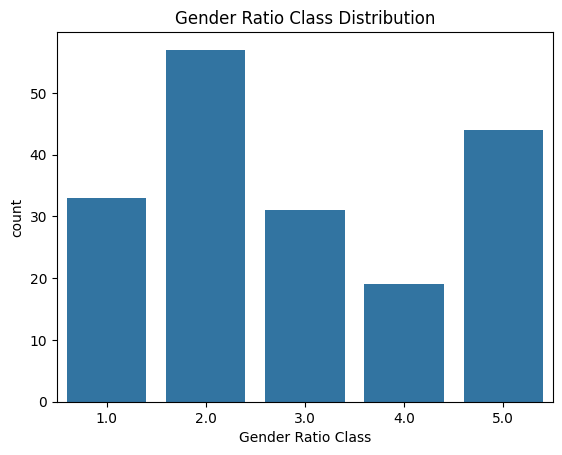

In [8]:
df['Gender Ratio Class'].value_counts(normalize=True)

sns.countplot(data=df, x='Gender Ratio Class')
plt.title('Gender Ratio Class Distribution')
plt.show()

## 7. Exploratory Data Analysis (EDA)

In [9]:
important_numeric = [
    # Labor participation
    'Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)',
    'Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)',

    # Unemployment
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',

    # Education
    'School enrollment, secondary (% gross)',
    'School enrollment, tertiary (% gross)'
]

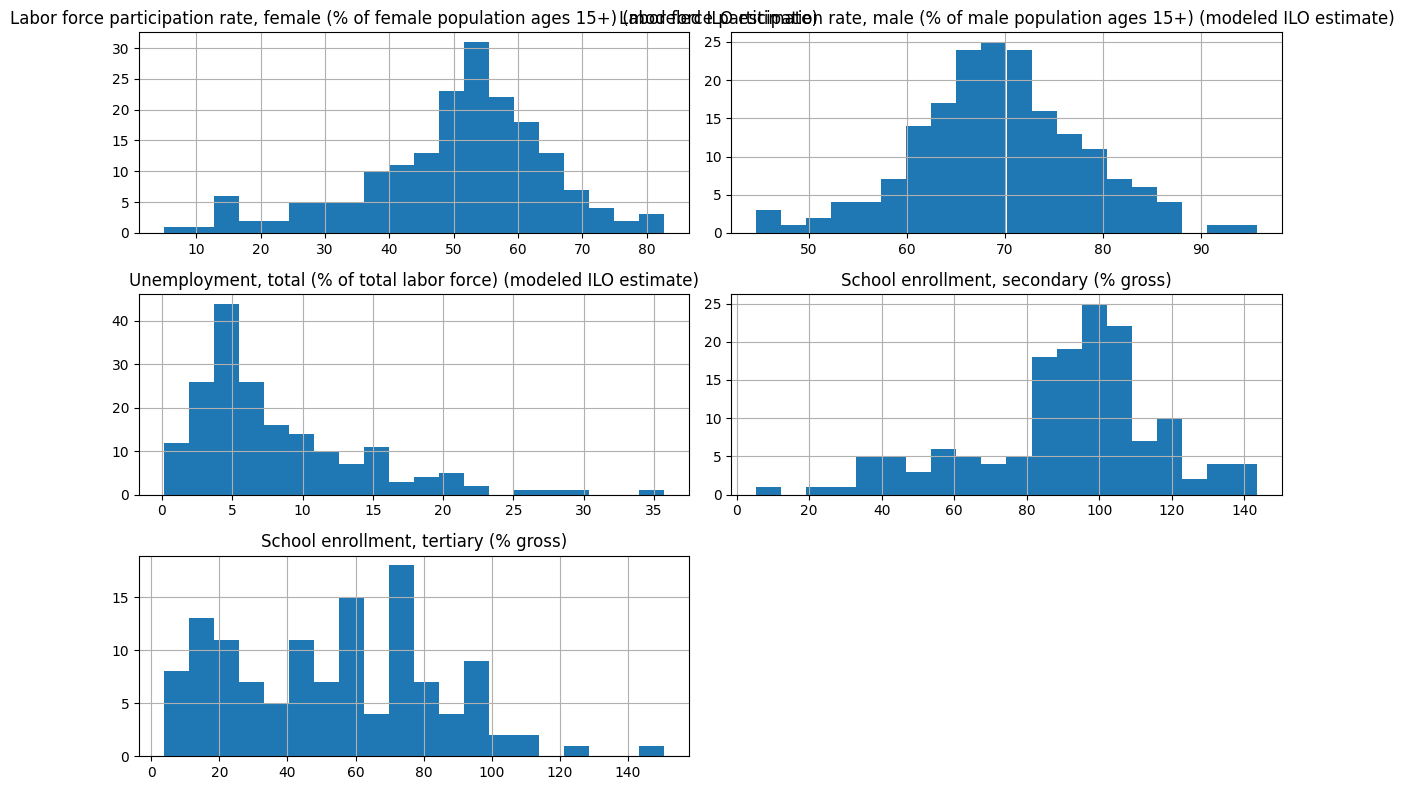

In [10]:
df[important_numeric].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

## 8. Data Cleaning & Preparation

In [11]:
#drop Gender Ratio Class
df = df.dropna(subset=['Gender Ratio Class'])

In [12]:
#drop cloumns ที่ไม่ช่วยในการทำ model
df = df.drop(columns=['Country Name', 'CountryName', 'Year'])

In [13]:
#drop columns ที่มีข้อมูลหายมากกว่า 50%
missing_ratio = df.isnull().mean()
df = df.drop(columns=missing_ratio[missing_ratio > 0.5].index)

In [14]:
#Categorical เติมด้วย mode Numeric เติมด้วย median 
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [15]:
df.head()

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Gender Ratio Class,Region,ThirdWorld
0,58.74,33.60,12.00,2099.0,125.67,5.20,114.32,1.85,12084.40,652230.0,...,109835608.0,0.34,8.500000e+08,5.308000e+09,43.16,60.87,12.79,1.0,South Asia,Yes
1,41.47,18.36,21.89,5144.7,114.68,97.84,104.92,28.79,7889.00,27400.0,...,6384226.0,8.41,3.559000e+09,7.718000e+09,62.89,27.58,15.96,1.0,Eastern Europe,No
2,17.35,11.23,3.16,1433.7,108.76,20.68,104.83,0.82,19583.33,2381741.0,...,109835608.0,3.95,3.863700e+10,3.746600e+10,40.86,2.10,1.61,1.0,Africa,No
5,36.81,11.49,4.31,1000.1,116.22,5.61,117.50,52.98,660523.13,1246700.0,...,43596708.0,12.20,3.447200e+10,1.137900e+10,68.94,5.59,3.34,5.0,Africa,Yes
7,43.10,7.31,15.42,5193.0,107.19,62.18,108.40,10.40,284636.67,2736690.0,...,466425814.0,42.34,7.793500e+10,6.318500e+10,28.92,0.85,0.31,4.0,South America,No


In [16]:
df.info()
df.isnull().sum().sort_values(ascending=False).head()

<class 'pandas.core.frame.DataFrame'>
Index: 184 entries, 0 to 213
Columns: 109 entries, Agricultural land (% of land area) to ThirdWorld
dtypes: float64(107), object(2)
memory usage: 158.1+ KB


Agricultural land (% of land area)                    0
Age dependency ratio (% of working-age population)    0
Net migration                                         0
Life expectancy at birth, total (years)               0
Life expectancy at birth, male (years)                0
dtype: int64

## Part 1.1

## Workflow 1: Baseline Model

In [17]:
# Separate features (X) and target variable (y) for classification modeling
X = df.drop(columns=['Gender Ratio Class'])
y = df['Gender Ratio Class']

In [18]:
# Train-test split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
# Separate numerical and categorical feature columns
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

In [20]:
# Define preprocessing steps for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [21]:
# Initialize Logistic Regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [22]:
# Combine preprocessing and model into a single pipeline
clf = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ]
)

In [23]:
# Train the classification model using the training dataset
clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [24]:
# Evaluate model performance on the test dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
y_pred = clf.predict(X_test)

print("Accuracy (macro):", accuracy_score(y_test, y_pred))
print("F1 score (macro):", f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy (macro): 0.1891891891891892
F1 score (macro): 0.18329670329670328

Classification Report:

              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         7
         2.0       0.20      0.27      0.23        11
         3.0       0.22      0.33      0.27         6
         4.0       0.33      0.25      0.29         4
         5.0       0.17      0.11      0.13         9

    accuracy                           0.19        37
   macro avg       0.18      0.19      0.18        37
weighted avg       0.17      0.19      0.18        37



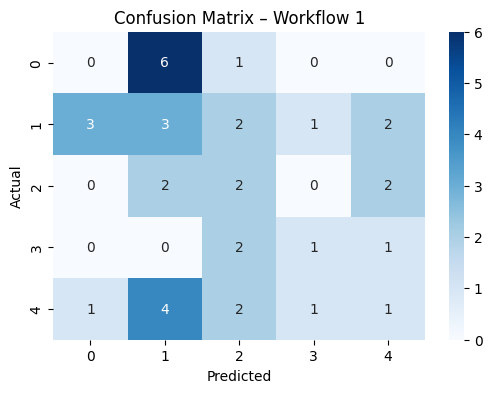

In [25]:
# Plot confusion matrix for Workflow 1
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Workflow 1')
plt.show()

## Workflow 2: Improved Model

In [26]:
# Selected feature subset for Workflow 2
selected_features_w2 = [
    'Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)',
    'Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',
    'School enrollment, secondary (% gross)',
    'School enrollment, tertiary (% gross)',
    'Region'
]

In [27]:
# Define features and target variable for Workflow 2
X_w2 = df[selected_features_w2]
y = df['Gender Ratio Class']

In [28]:
# Apply the same train-test split for Workflow 2
X_train_w2 = X_w2.loc[X_train.index]
X_test_w2  = X_w2.loc[X_test.index]

In [29]:
# Define preprocessing steps for Workflow 2
num_cols_w2 = X_w2.select_dtypes(include='number').columns
cat_cols_w2 = X_w2.select_dtypes(exclude='number').columns

preprocessor_w2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_w2),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_w2)
    ]
)

In [30]:
# Initialize SVM model for Workflow 2
from sklearn.svm import SVC
model_w2 = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

In [31]:
# Combine preprocessing and SVM model into a single pipeline for Workflow 2
clf_w2 = Pipeline(
    steps=[
        ('preprocess', preprocessor_w2),
        ('model', model_w2)
    ]
)

In [32]:
# Train the Workflow 2 classification model
clf_w2.fit(X_train_w2, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [33]:
# Predict class labels for Workflow 2
y_pred_w2 = clf_w2.predict(X_test_w2)

In [34]:
# Evaluate Workflow 2 classification performance
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print("Workflow 2 Accuracy (macro):", accuracy_score(y_test, y_pred_w2))
print("Workflow 2 F1 (macro):", f1_score(y_test, y_pred_w2, average='macro'))

print("\nClassification Report (Workflow 2):\n")
print(classification_report(y_test, y_pred_w2))

Workflow 2 Accuracy (macro): 0.35135135135135137
Workflow 2 F1 (macro): 0.2249624060150376

Classification Report (Workflow 2):

              precision    recall  f1-score   support

         1.0       0.67      0.29      0.40         7
         2.0       0.38      0.82      0.51        11
         3.0       0.00      0.00      0.00         6
         4.0       0.00      0.00      0.00         4
         5.0       0.20      0.22      0.21         9

    accuracy                           0.35        37
   macro avg       0.25      0.27      0.22        37
weighted avg       0.29      0.35      0.28        37



/opt/homebrew/Cellar/jupyterlab/4.5.0_1/libexec/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Cellar/jupyterlab/4.5.0_1/libexec/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Cellar/jupyterlab/4.5.0_1/libexec/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

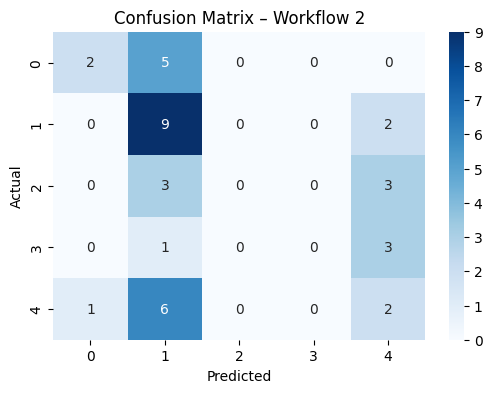

In [35]:
# Plot confusion matrix for Workflow 2
import seaborn as sns
import matplotlib.pyplot as plt

cm_w2 = confusion_matrix(y_test, y_pred_w2)

plt.figure(figsize=(6,4))
sns.heatmap(cm_w2, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix – Workflow 2')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Workflow 3: Final Model

In [36]:
# Final selected feature set for Workflow 3
selected_features_w3 = [
    'Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)',
    'Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',
    'School enrollment, secondary (% gross)',
    'School enrollment, tertiary (% gross)',
    'Region'
]

In [37]:
# Define features and target for Workflow 3
X_w3 = df[selected_features_w3]
y = df['Gender Ratio Class']

In [38]:
# Apply the same train-test split for Workflow 3
X_train_w3 = X_w3.loc[X_train.index]
X_test_w3  = X_w3.loc[X_test.index]

In [39]:
# Define preprocessing steps for Workflow 3
num_cols_w3 = X_w3.select_dtypes(include='number').columns
cat_cols_w3 = X_w3.select_dtypes(exclude='number').columns

preprocessor_w3 = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols_w3),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_w3)
    ]
)

In [40]:
# Initialize Decision Tree model for Workflow 3
from sklearn.tree import DecisionTreeClassifier
model_w3 = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=3,
    random_state=42
)

In [41]:
# Final pipeline for Workflow 3
clf_w3 = Pipeline(
    steps=[
        ('preprocess', preprocessor_w3),
        ('model', model_w3)
    ]
)

In [42]:
# Train the final classification model
clf_w3.fit(X_train_w3, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [43]:
# Predict test set labels for Workflow 3
y_pred_w3 = clf_w3.predict(X_test_w3)

In [44]:
# Evaluate final model performance
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print("Workflow 3 Accuracy (macro):", accuracy_score(y_test, y_pred_w3))
print("Workflow 3 F1 (macro):", f1_score(y_test, y_pred_w3, average='macro'))

print("\nClassification Report (Workflow 3):\n")
print(classification_report(y_test, y_pred_w3))

Workflow 3 Accuracy (macro): 0.32432432432432434
Workflow 3 F1 (macro): 0.21775572098152743

Classification Report (Workflow 3):

              precision    recall  f1-score   support

         1.0       0.50      0.43      0.46         7
         2.0       0.40      0.73      0.52        11
         3.0       0.00      0.00      0.00         6
         4.0       0.00      0.00      0.00         4
         5.0       0.11      0.11      0.11         9

    accuracy                           0.32        37
   macro avg       0.20      0.25      0.22        37
weighted avg       0.24      0.32      0.27        37



/opt/homebrew/Cellar/jupyterlab/4.5.0_1/libexec/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Cellar/jupyterlab/4.5.0_1/libexec/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Cellar/jupyterlab/4.5.0_1/libexec/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

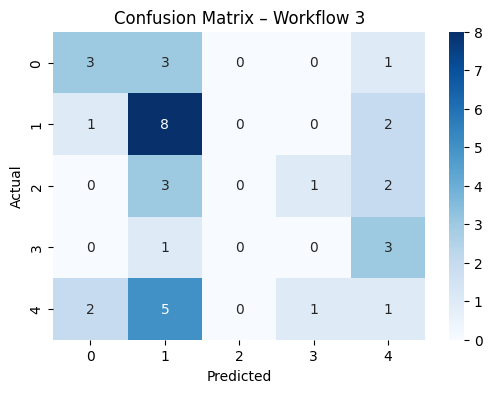

In [45]:
# Plot confusion matrix for the final model
cm_w3 = confusion_matrix(y_test, y_pred_w3)

plt.figure(figsize=(6,4))
sns.heatmap(cm_w3, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix – Workflow 3')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [46]:
# Compute feature importance for the final model
feature_names = clf_w3.named_steps['preprocess'].get_feature_names_out()
importances = clf_w3.named_steps['model'].feature_importances_

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
fi

num__Unemployment, total (% of total labor force) (modeled ILO estimate)                                0.310179
num__Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)    0.191410
num__Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)        0.162262
num__School enrollment, tertiary (% gross)                                                              0.139416
cat__Region_Middle East                                                                                 0.121537
num__School enrollment, secondary (% gross)                                                             0.075197
cat__Region_Northern Europe                                                                             0.000000
cat__Region_Western Asia                                                                                0.000000
cat__Region_Southeast Asia                                                                      